<!-- WARNING: THIS FILE WAS AUTOGENERATED! DO NOT EDIT! -->

In [0]:
#| echo: false
#| output: asis
show_doc(subset_common_cells)

---

[source](https://github.com/cobioda/allos/blob/main/allos/preprocessing.py#L19){target="_blank" style="float:right; font-size:smaller"}

### subset_common_cells

>      subset_common_cells (dataset1:anndata._core.anndata.AnnData,
>                           dataset2:anndata._core.anndata.AnnData)

*Subset `dataset1` to only include cells that are also present in `dataset2`.*

|    | **Type** | **Details** |
| -- | -------- | ----------- |
| dataset1 | AnnData | First dataset to be subsetted. |
| dataset2 | AnnData | Second dataset to compare with. |
| **Returns** | **AnnData** | **Subset of `dataset1` containing only cells also found in `dataset2`.** |

In [0]:
#| echo: false
#| output: asis
show_doc(transfer_obs)

---

[source](https://github.com/cobioda/allos/blob/main/allos/preprocessing.py#L37){target="_blank" style="float:right; font-size:smaller"}

### transfer_obs

>      transfer_obs (dataset1:anndata._core.anndata.AnnData,
>                    dataset2:anndata._core.anndata.AnnData)

*Transfer `.obs` metadata from `dataset1` to `dataset2` one by one, while preserving the `.var` DataFrame of `dataset2`.*

|    | **Type** | **Details** |
| -- | -------- | ----------- |
| dataset1 | AnnData | Source AnnData object with .obs metadata to transfer. |
| dataset2 | AnnData | Target AnnData object to receive .obs metadata. |
| **Returns** | **AnnData** | **The modified `dataset2` with .obs from `dataset1` transferred.** |

In [5]:
combined_mouse_data = process_mouse_data()


🔎 Looking for file at: /home/diamant/.conda/envs/iso_swt/lib/python3.9/site-packages/allos/resources/e18.mouse.clusters.csv
✅ File found at: /home/diamant/.conda/envs/iso_swt/lib/python3.9/site-packages/allos/resources/e18.mouse.clusters.csv
✅ File already exists at: /home/diamant/.conda/envs/iso_swt/lib/python3.9/site-packages/allos/resources/data/mouse_1.txt.gz

🔄 Decompressing /home/diamant/.conda/envs/iso_swt/lib/python3.9/site-packages/allos/resources/data/mouse_1.txt.gz to /home/diamant/.conda/envs/iso_swt/lib/python3.9/site-packages/allos/resources/data/mouse_1.txt...
✅ Decompression complete.
Test data (mouse_1) downloaded successfully
✅ File already exists at: /home/diamant/.conda/envs/iso_swt/lib/python3.9/site-packages/allos/resources/data/mouse_2.txt.gz

🔄 Decompressing /home/diamant/.conda/envs/iso_swt/lib/python3.9/site-packages/allos/resources/data/mouse_2.txt.gz to /home/diamant/.conda/envs/iso_swt/lib/python3.9/site-packages/allos/resources/data/mouse_2.txt...
✅ Decom

/home/diamant/.local/lib/python3.9/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [0]:
#| echo: false
#| output: asis
show_doc(get_sot_gene_matrix)

---

[source](https://github.com/cobioda/allos/blob/main/allos/preprocessing.py#L64){target="_blank" style="float:right; font-size:smaller"}

### get_sot_gene_matrix

>      get_sot_gene_matrix (adata)

*Construct a gene-level count matrix from transcript-level data.*

|    | **Type** | **Details** |
| -- | -------- | ----------- |
| adata | AnnData | Input AnnData with transcript-level counts. Must have a column `geneId`<br>in `adata.var` containing the gene ID for each transcript. |
| **Returns** | **AnnData** | **A new AnnData object where columns (var) represent unique genes, <br>and values are aggregated transcript counts.** |

In [0]:
#| echo: false
#| output: asis
show_doc(compute_transcript_abundance_pct)

---

[source](https://github.com/cobioda/allos/blob/main/allos/preprocessing.py#L117){target="_blank" style="float:right; font-size:smaller"}

### compute_transcript_abundance_pct

>      compute_transcript_abundance_pct (adata)

*Compute transcript abundance percentages ("percent spliced in") for each transcript 
within its gene. For each cell and transcript, this is computed as:

transcript_pct = (transcript count / total gene count) * 100*

|    | **Type** | **Details** |
| -- | -------- | ----------- |
| adata | AnnData | AnnData object with transcript-level counts. Must have a column 'geneId' in adata.var. |
| **Returns** | **AnnData** | **A new AnnData object with the same obs and var as the input, where X holds <br>transcript abundance percentages.** |

In [0]:
#| echo: false
#| output: asis
show_doc(compute_whole_data_transcript_abundance)

---

[source](https://github.com/cobioda/allos/blob/main/allos/preprocessing.py#L160){target="_blank" style="float:right; font-size:smaller"}

### compute_whole_data_transcript_abundance

>      compute_whole_data_transcript_abundance (adata)

*Compute transcript abundance percentages for the entire dataset by aggregating 
transcript counts across all cells into a single composite sample.

This function sums the transcript counts over all cells, constructs a new AnnData 
with a single observation, and then computes transcript abundance percentages 
using compute_transcript_abundance_pct.*

|    | **Type** | **Details** |
| -- | -------- | ----------- |
| adata | AnnData | AnnData object with transcript-level counts. Must have a 'geneId' column in adata.var. |
| **Returns** | **AnnData** | **A new AnnData object with one observation representing the aggregated data <br>where X holds transcript abundance percentages.** |

In [0]:
#| echo: false
#| output: asis
show_doc(filter_transcripts_by_abundance)

---

[source](https://github.com/cobioda/allos/blob/main/allos/preprocessing.py#L204){target="_blank" style="float:right; font-size:smaller"}

### filter_transcripts_by_abundance

>      filter_transcripts_by_abundance (adata, threshold_pct, verbose=False)

*Filter transcripts from an AnnData object based on their overall transcript abundance percentage,
computed by aggregating transcript counts across all cells and leveraging overall gene counts.

The overall abundance percentage for each transcript is calculated as:

    overall_pct = (total transcript count) / (total gene count for its gene) * 100

This function uses the compute_whole_data_transcript_abundance function internally to leverage the gene
mapping information (via the 'geneId' in adata.var). Transcripts with an overall abundance
percentage below the specified threshold (threshold_pct) are filtered out.*

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| adata | AnnData |  | AnnData object with transcript-level counts. Must have a 'geneId' column in adata.var. |
| threshold_pct | float |  | Minimum overall transcript abundance percentage required to keep a transcript. |
| verbose | bool | False | If True, prints the number of transcripts kept and the threshold used. Default is False. |
| **Returns** | **AnnData** |  | **A new AnnData object with the filtered transcript matrix.** |

In [0]:
#| echo: false
#| output: asis
show_doc(plot_isoform_overview)

---

[source](https://github.com/cobioda/allos/blob/main/allos/preprocessing.py#L284){target="_blank" style="float:right; font-size:smaller"}

### plot_isoform_overview

>      plot_isoform_overview (adata, celltype_col:str='cell_type',
>                             min_counts:int=1, figsize:tuple=(18, 6),
>                             save:Optional[str]=None)

*Reproduce the three-panel overview:

① Stacked bar: single-isoform vs multi-isoform genes + total transcripts
② Histogram: frequency of *n* isoforms per gene
③ Box/strip plot: genes detected per cell, grouped by cell type*

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| adata | AnnData |  | Transcript-level AnnData with `geneId` in ``adata.var``. |
| celltype_col | str | cell_type | column in adata.obs for panel-3 grouping |
| min_counts | int | 1 | >0 = gene “expressed” |
| figsize | tuple | (18, 6) | Figure size passed to ``plt.subplots``. |
| save | Optional | None | path to PNG/PDF if you want to save |

In [11]:
combined_mouse_data_filtered = filter_transcripts_by_abundance(combined_mouse_data, threshold_pct= 2)

In [12]:
combined_mouse_data_filtered

AnnData object with n_obs × n_vars = 1109 × 24917
    obs: 'batch', 'cell_type'
    var: 'geneId'

In [13]:
combined_mouse_data

View of AnnData object with n_obs × n_vars = 1109 × 31986
    obs: 'batch', 'cell_type'
    var: 'geneId'

In [14]:
gene_adata = get_sot_gene_matrix(combined_mouse_data)

In [15]:
gene_adata

AnnData object with n_obs × n_vars = 1109 × 12561
    obs: 'batch', 'cell_type'

In [18]:
combined_mouse_data.var['transcriptId'] = combined_mouse_data.var.index

/tmp/ipykernel_2829472/542314017.py:1: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  combined_mouse_data.var['transcriptId'] = combined_mouse_data.var.index


/tmp/ipykernel_2829472/2152868992.py:120: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha="right")
/tmp/ipykernel_2829472/2152868992.py:145: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha="right")


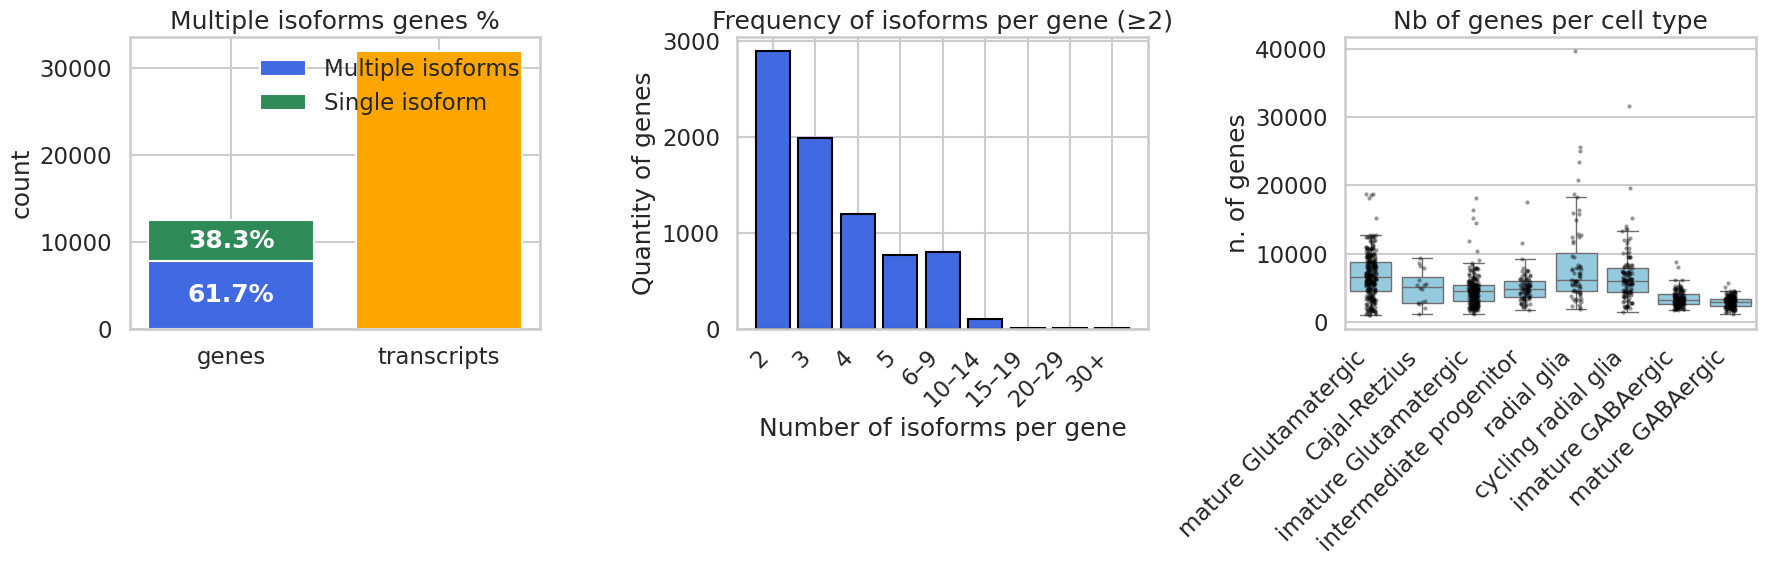

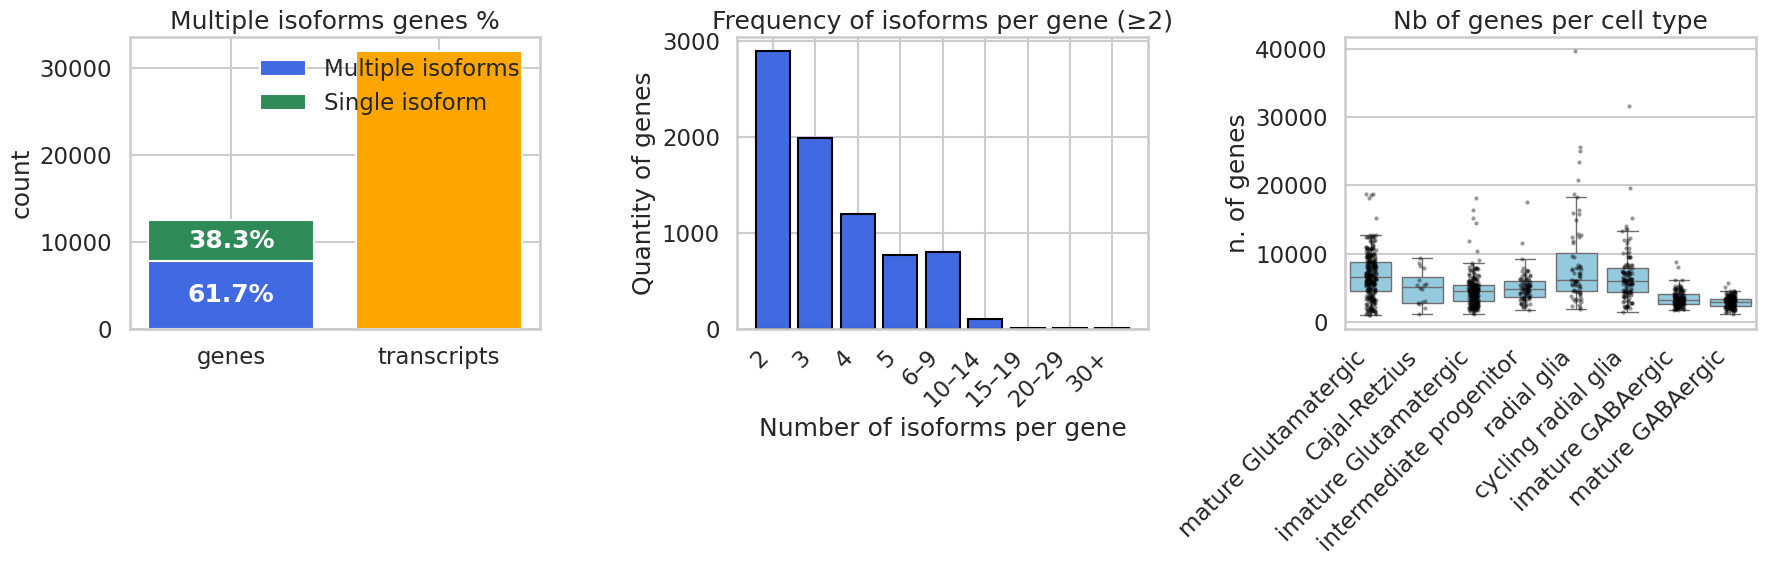

In [23]:
plot_isoform_overview(
    combined_mouse_data,
    celltype_col="cell_type",     # adjust to your obs column
    save="isoform_overview.png",   # optional
    min_counts=1,           # >0 = gene “expressed”
)

In [0]:
#| echo: false
#| output: asis
show_doc(gene_wise_correlation)

/home/mcandrew/.local/lib/python3.10/site-packages/fastcore/docscrape.py:230: UserWarning: Unknown section Note
  else: warn(msg)


---

[source](https://github.com/cobioda/allos/blob/main/allos/preprocessing.py#L442){target="_blank" style="float:right; font-size:smaller"}

### gene_wise_correlation

>      gene_wise_correlation (adata_1, adata_2, label_1='Short_Reads',
>                             label_2='Long_Reads', density_hist=True,
>                             facet_obs=None)

*Generalized function to compute gene-level counts for each dataset, merge them,
and plot a log correlation. If facet_obs is specified, creates per-category plots.*

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| adata_1 | AnnData |  | First AnnData, presumably transcript-level. Must have a 'geneId' column in .var. |
| adata_2 | AnnData |  | Second AnnData, presumably transcript-level. Must have a 'geneId' column in .var. |
| label_1 | str | Short_Reads | Label for the first dataset in the merged DataFrame and on plots. |
| label_2 | str | Long_Reads | Label for the second dataset in the merged DataFrame and on plots. |
| density_hist | bool | True | If True, display a scatter with marginal histograms. Otherwise, just a scatter. |
| facet_obs | NoneType | None | If provided, facet by the unique categories in adata_1.obs[facet_obs] and<br>subset adata_2 identically, producing one subplot per category. |
| **Returns** | **pd.DataFrame** |  | **- If facet_obs is None: a DataFrame of shape [n_genes, 5] with columns:<br>    ['gene_name', label_1, label_2, 'log_x', 'log_y'].<br>- If facet_obs is not None: a concatenated DataFrame of all categories,<br>  with an extra column 'facet' indicating the category.** |

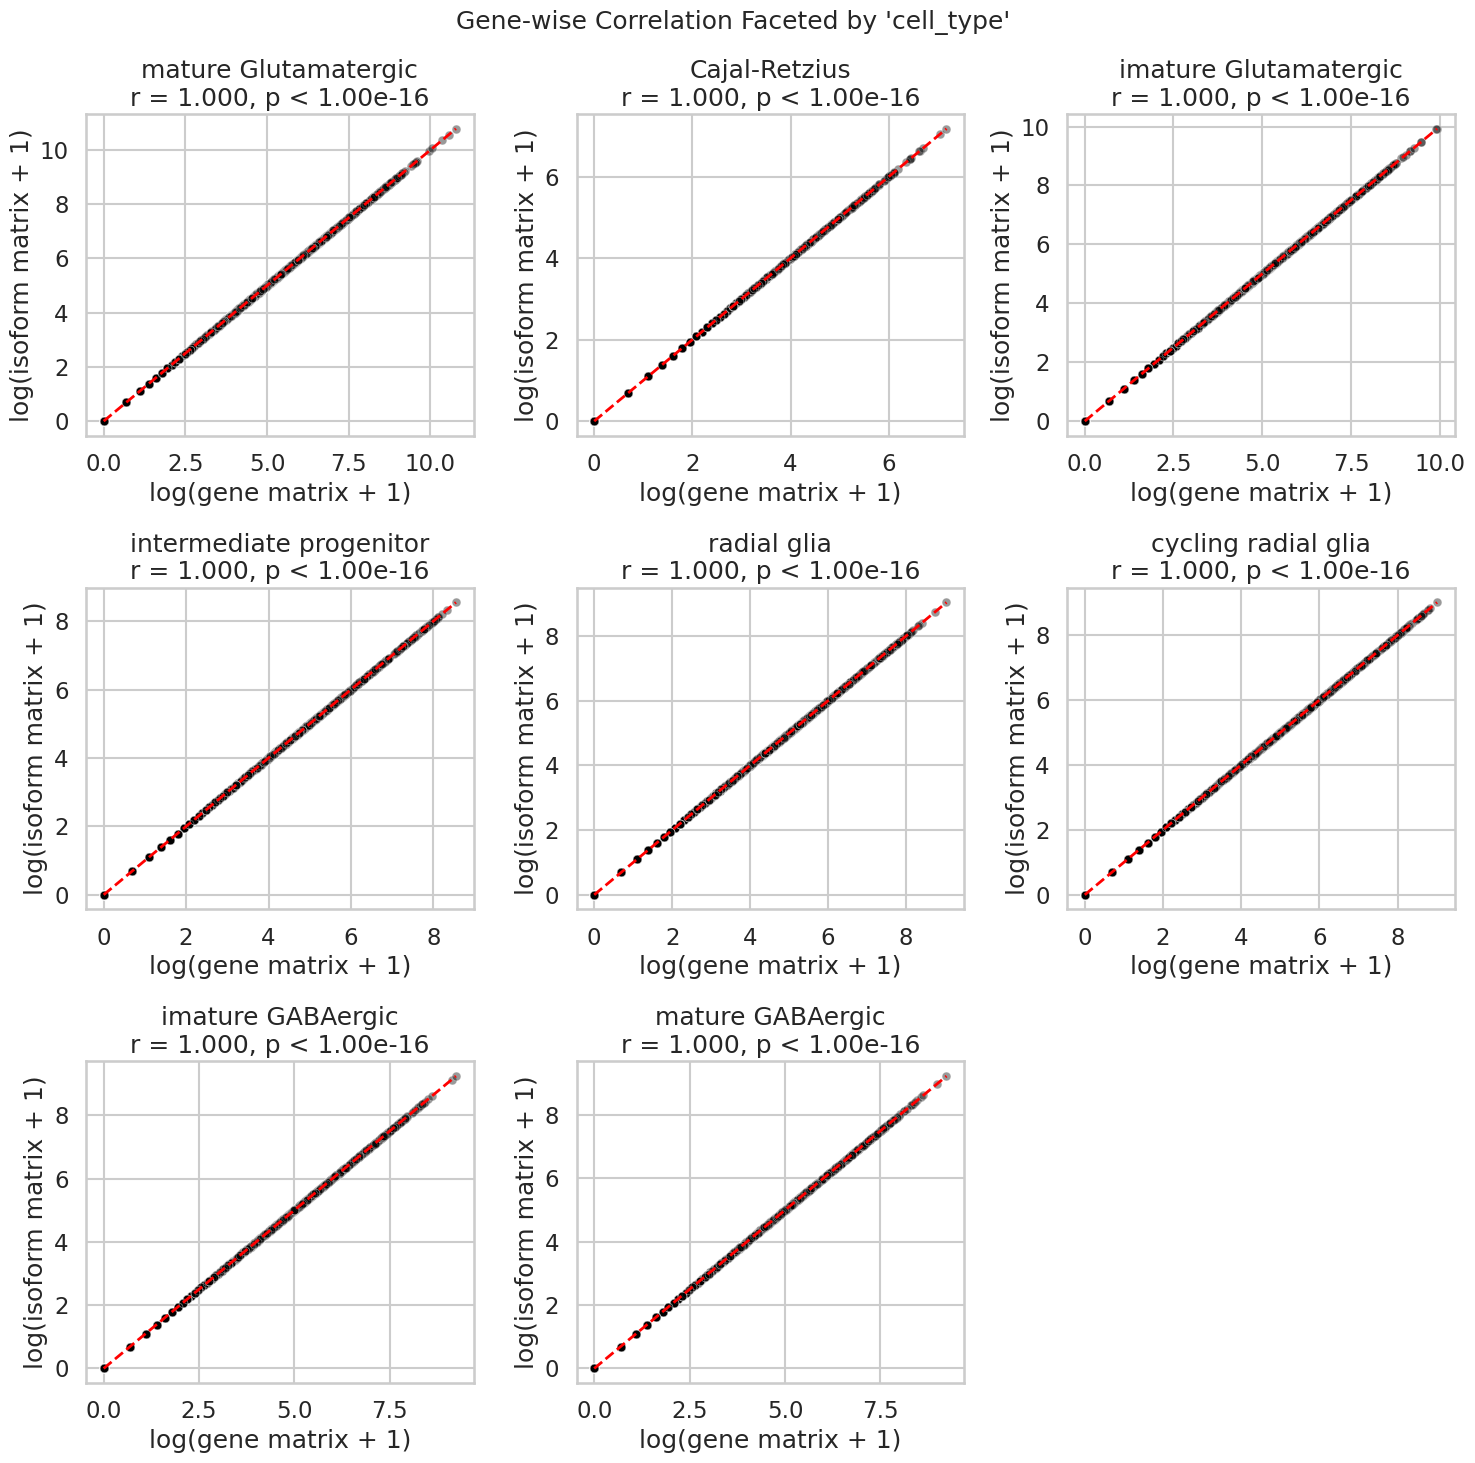

In [ ]:
gene_wise_correlation(adata_1=gene_adata, adata_2=combined_mouse_data, label_1="gene matrix", label_2 = "isoform matrix", density_hist = True, facet_obs = "cell_type")

In [0]:
#| echo: false
#| output: asis
show_doc(gene_wise_bland_altman)

---

[source](https://github.com/cobioda/allos/blob/main/allos/preprocessing.py#L667){target="_blank" style="float:right; font-size:smaller"}

### gene_wise_bland_altman

>      gene_wise_bland_altman (adata_1, adata_2, label_1='Short_Reads',
>                              label_2='Long_Reads', facet_obs=None)

*Similar logic to gene_wise_correlation, but produces a Bland–Altman plot of the
log1p-transformed gene counts. If facet_obs is given, one subplot per category.

Steps:
 1) (Optionally) convert each AnnData to gene-level if needed.
 2) Sum counts across cells in each AnnData.
 3) Merge on gene_name.
 4) Bland–Altman: difference vs. mean of log1p(counts).*

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| adata_1 | AnnData |  |  |
| adata_2 | AnnData |  | Both should be gene-level or convertible to gene-level (e.g., via get_sot_gene_matrix). |
| label_1 | str | Short_Reads | Label for the first dataset in merged outputs & plot axes. |
| label_2 | str | Long_Reads | Label for the second dataset in merged outputs & plot axes. |
| facet_obs | NoneType | None | If not None, create one subplot per category in `adata_1.obs[facet_obs]`. |
| **Returns** | **pd.DataFrame** |  | **- If facet_obs is None: a single DataFrame with columns<br>  [gene_name, label_1, label_2, log_x, log_y, mean_val, diff_val].<br>- If facet_obs is not None: concatenated DataFrame with all categories,<br>  plus 'facet' indicating each category.** |

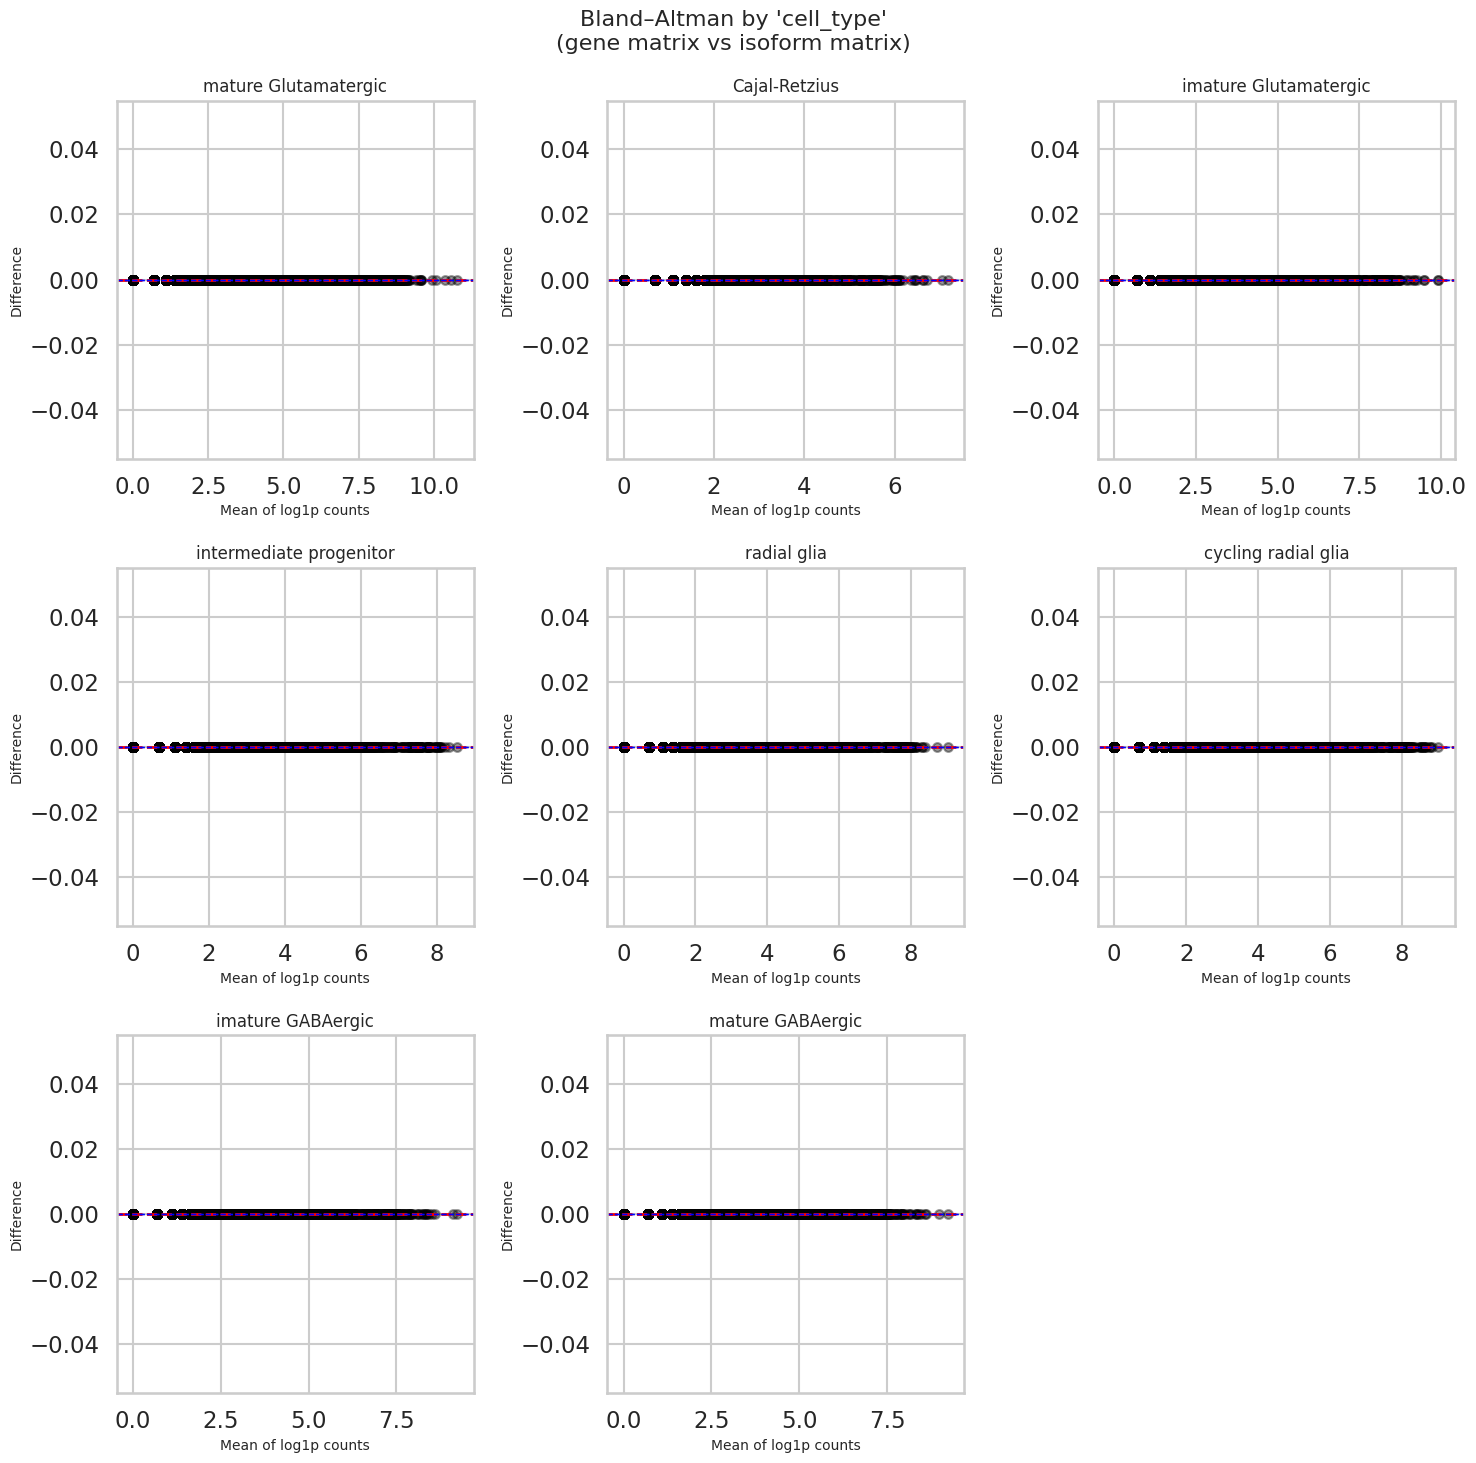

In [ ]:
gene_wise_bland_altman(adata_1=gene_adata, adata_2=combined_mouse_data, label_1="gene matrix", label_2 = "isoform matrix", facet_obs = "cell_type")

In [ ]:
import nbdev; nbdev.nbdev_export()